# 📊 Phishing Detection - Statistics & Visualization

This notebook provides comprehensive analysis and visualization of phishing detection results.

**Visualizations**:
1. Classification Distribution
2. MITRE ATT&CK Tactics Heatmap
3. Confidence Score Distribution
4. Severity Analysis
5. Feature Correlation

In [1]:
!pip install pandas matplotlib seaborn

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

In [3]:
# Load classified emails
df = pd.read_csv('/home/jovyan/data/classified_emails.csv')

print(f"📊 Loaded {len(df)} classified emails")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst few rows:")
df.head()

📊 Loaded 100 classified emails

Columns: ['event_id', 'timestamp', 'email_id', 'subject', 'body', 'sender', 'original_label', 'classification', 'confidence', 'mitre_tactic', 'mitre_technique_id', 'mitre_technique_name', 'severity', 'has_suspicious_link', 'has_urgency', 'has_credential_request', 'classified_at']

First few rows:


,event_id,timestamp,email_id,subject,body,sender,original_label,classification,confidence,mitre_tactic,mitre_technique_id,mitre_technique_name,severity,has_suspicious_link,has_urgency,has_credential_request,classified_at
0,f044f3e1-226e-40b2-98e2-175e908442dc,2026-02-11T16:24:58.175796,5,URGENT: Password expires today,Your email password expires TODAY! Click this ...,admin@google-mail-security.xyz,phishing,phishing,0.618784,Credential Access,T1598.003,Phishing for Information: Spearphishing Link,critical,True,True,True,2026-02-11T16:34:59.992455
1,85c4b756-1300-40f5-b014-ea597910e5c1,2026-02-11T16:24:58.226732,6,Lunch plans?,"Hey, want to grab lunch today? There's a new T...",sarah@company.com,legitimate,legitimate,0.710892,NaN,NaN,Legitimate Email,none,False,True,False,2026-02-11T16:34:59.993989
2,81fc4216-45c3-4c80-89b6-dc72b3694304,2026-02-11T16:24:58.379450,9,RE: Project deadline,Thanks for the update. I'll have my part ready...,mike@company.com,legitimate,legitimate,0.723158,NaN,NaN,Legitimate Email,none,False,False,False,2026-02-11T16:34:59.994733
3,8735bee2-ce8a-4d2e-b77e-34877e26b6c0,2026-02-11T16:24:58.431571,10,Claim your free iPhone 15!,You've been selected! Get your FREE iPhone 15 ...,deals@free-iphone-winner.net,phishing,phishing,0.585286,Initial Access,T1566,Phishing,medium,False,False,False,2026-02-11T16:34:59.995480
4,1b649ca0-decc-423f-903d-bbcc8041fb1d,2026-02-11T16:24:58.484250,11,Weekly newsletter,Here's your weekly tech news roundup. Top stor...,newsletter@technews.com,legitimate,legitimate,0.752241,NaN,NaN,Legitimate Email,none,False,False,False,2026-02-11T16:34:59.996235


In [4]:
# Basic Statistics
print("="*60)
print("📈 PHISHING DETECTION STATISTICS")
print("="*60)

total = len(df)
phishing = len(df[df['classification'] == 'phishing'])
legitimate = len(df[df['classification'] == 'legitimate'])

print(f"\n📧 Total Emails Analyzed: {total}")
print(f"🚨 Phishing Detected: {phishing} ({phishing/total:.1%})")
print(f"✅ Legitimate: {legitimate} ({legitimate/total:.1%})")

# Accuracy check
if 'original_label' in df.columns:
    correct = ((df['classification'] == 'phishing') == (df['original_label'] == 'phishing')).sum()
    print(f"\n🎯 Model Accuracy: {correct/total:.1%}")

📈 PHISHING DETECTION STATISTICS

📧 Total Emails Analyzed: 100
🚨 Phishing Detected: 37 (37.0%)
✅ Legitimate: 63 (63.0%)

🎯 Model Accuracy: 100.0%


## 📊 Visualization 1: Classification Distribution

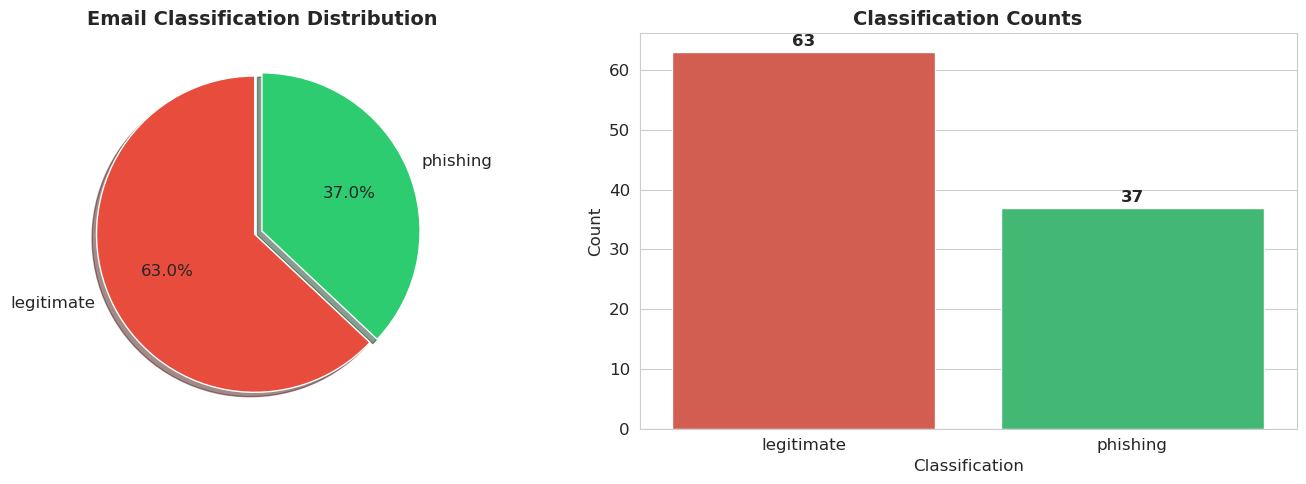

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
colors = ['#e74c3c', '#2ecc71']
classification_counts = df['classification'].value_counts()
axes[0].pie(classification_counts, labels=classification_counts.index, autopct='%1.1f%%', 
            colors=colors, explode=(0.05, 0), shadow=True, startangle=90)
axes[0].set_title('Email Classification Distribution', fontsize=14, fontweight='bold')

# Bar chart
sns.barplot(x=classification_counts.index, y=classification_counts.values, 
            palette=colors, ax=axes[1], hue=classification_counts.index, legend=False)
axes[1].set_title('Classification Counts', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Classification')
axes[1].set_ylabel('Count')

# Add value labels
for i, v in enumerate(classification_counts.values):
    axes[1].text(i, v + 1, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('/home/jovyan/data/viz1_classification.png', dpi=150, bbox_inches='tight')
plt.show()

## 🎯 Visualization 2: MITRE ATT&CK Techniques

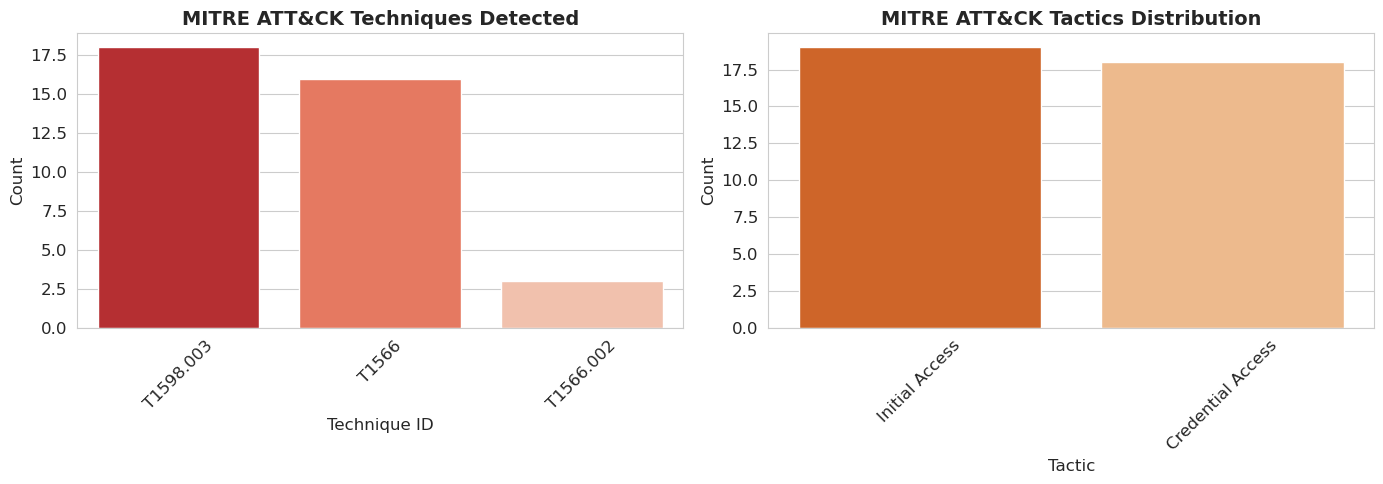

In [6]:
# Filter only phishing emails with MITRE mappings
phishing_df = df[df['classification'] == 'phishing'].copy()

if len(phishing_df) > 0 and 'mitre_technique_id' in phishing_df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Technique distribution
    technique_counts = phishing_df['mitre_technique_id'].value_counts()
    colors_mitre = sns.color_palette('Reds_r', len(technique_counts))
    
    sns.barplot(x=technique_counts.index, y=technique_counts.values, 
                palette=colors_mitre, ax=axes[0], hue=technique_counts.index, legend=False)
    axes[0].set_title('MITRE ATT&CK Techniques Detected', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Technique ID')
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Tactic distribution
    tactic_counts = phishing_df['mitre_tactic'].value_counts()
    colors_tactic = sns.color_palette('Oranges_r', len(tactic_counts))
    
    sns.barplot(x=tactic_counts.index, y=tactic_counts.values, 
                palette=colors_tactic, ax=axes[1], hue=tactic_counts.index, legend=False)
    axes[1].set_title('MITRE ATT&CK Tactics Distribution', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Tactic')
    axes[1].set_ylabel('Count')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.savefig('/home/jovyan/data/viz2_mitre.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No phishing emails detected or MITRE data not available.")

## 📈 Visualization 3: Confidence Score Distribution

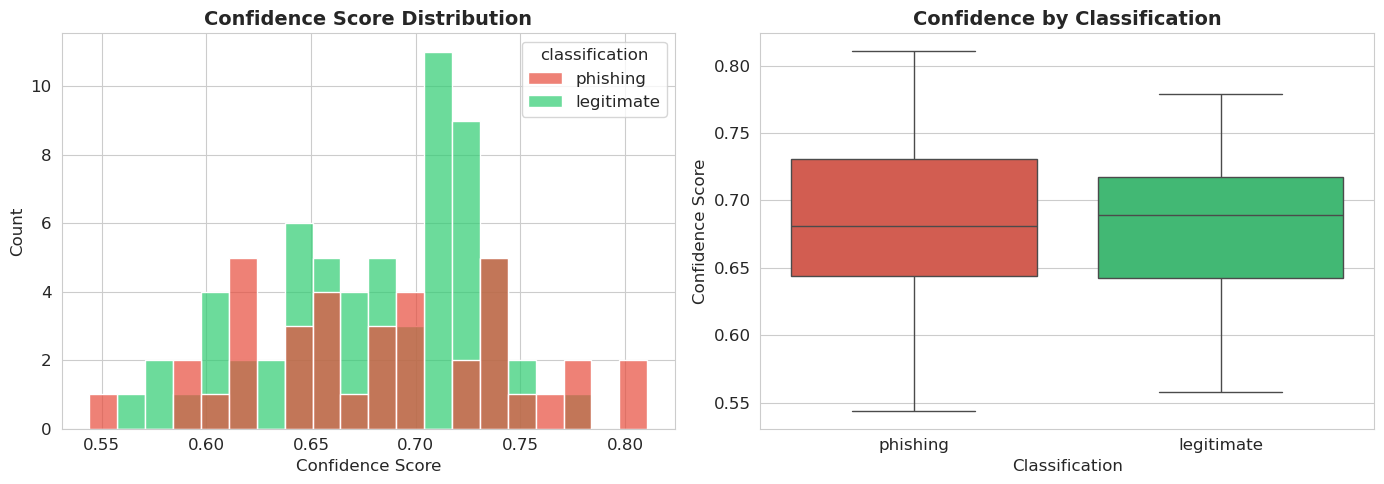

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of confidence scores
sns.histplot(data=df, x='confidence', hue='classification', bins=20, 
             palette=['#e74c3c', '#2ecc71'], ax=axes[0], alpha=0.7)
axes[0].set_title('Confidence Score Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Confidence Score')
axes[0].set_ylabel('Count')

# Box plot
sns.boxplot(data=df, x='classification', y='confidence', 
            palette=['#e74c3c', '#2ecc71'], ax=axes[1], hue='classification', legend=False)
axes[1].set_title('Confidence by Classification', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Classification')
axes[1].set_ylabel('Confidence Score')

plt.tight_layout()
plt.savefig('/home/jovyan/data/viz3_confidence.png', dpi=150, bbox_inches='tight')
plt.show()

## ⚠️ Visualization 4: Severity Analysis

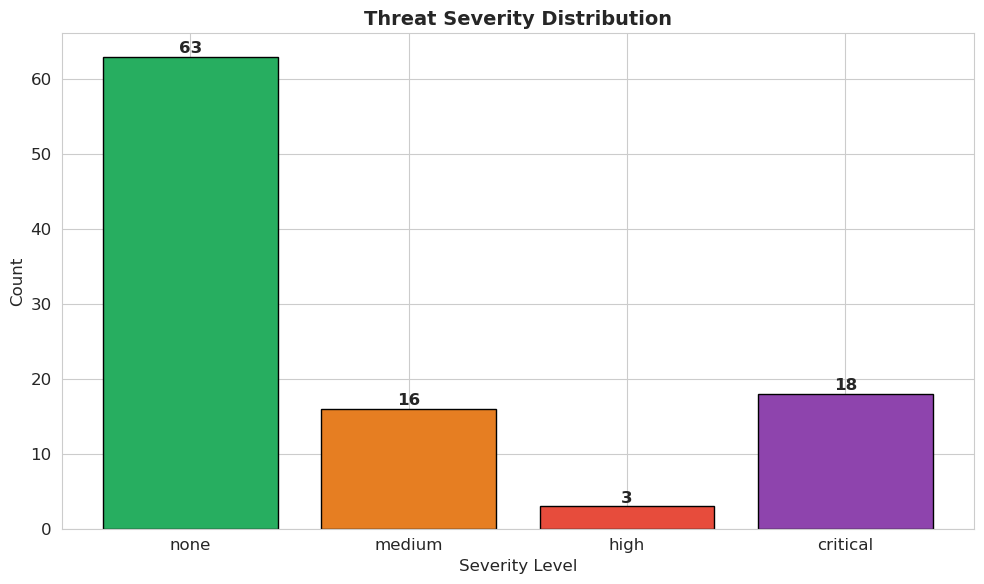

In [8]:
if 'severity' in df.columns:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Order severities
    severity_order = ['none', 'low', 'medium', 'high', 'critical']
    severity_counts = df['severity'].value_counts().reindex(severity_order).fillna(0)
    
    # Color gradient for severity
    colors_severity = ['#27ae60', '#f1c40f', '#e67e22', '#e74c3c', '#8e44ad']
    colors_present = [colors_severity[i] for i, s in enumerate(severity_order) if severity_counts[s] > 0]
    severity_counts = severity_counts[severity_counts > 0]
    
    bars = ax.bar(severity_counts.index, severity_counts.values, color=colors_present, edgecolor='black')
    ax.set_title('Threat Severity Distribution', fontsize=14, fontweight='bold')
    ax.set_xlabel('Severity Level')
    ax.set_ylabel('Count')
    
    # Add value labels
    for bar, value in zip(bars, severity_counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                f'{int(value)}', ha='center', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('/home/jovyan/data/viz4_severity.png', dpi=150, bbox_inches='tight')
    plt.show()

## 🔍 Visualization 5: Feature Analysis

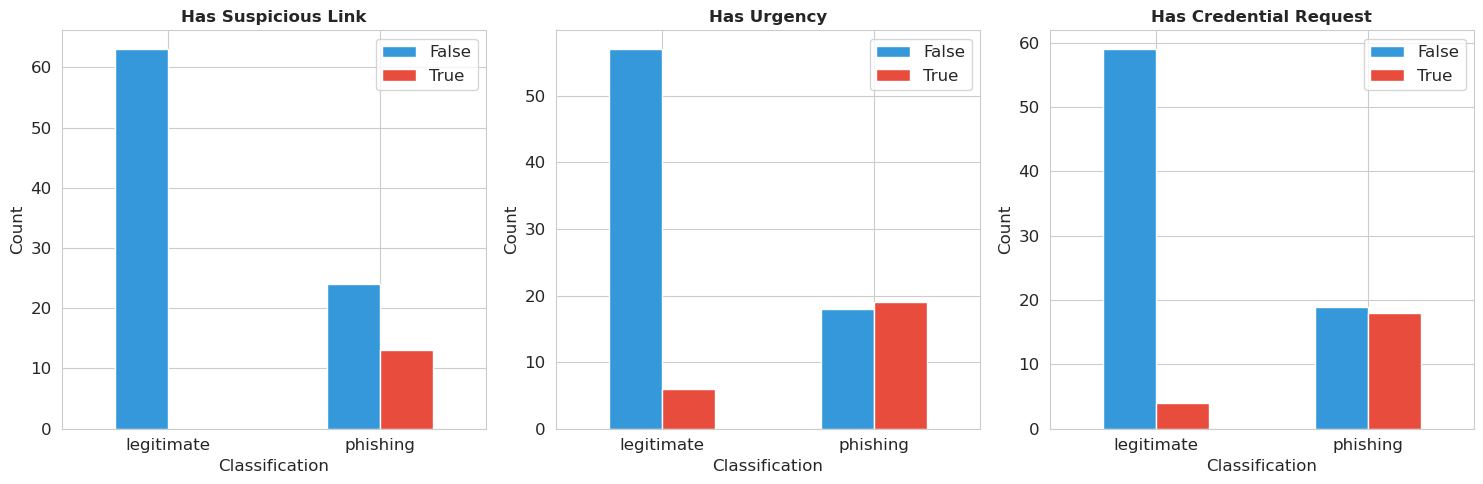

In [9]:
# Check if feature columns exist
feature_cols = ['has_suspicious_link', 'has_urgency', 'has_credential_request']
existing_features = [col for col in feature_cols if col in df.columns]

if existing_features:
    fig, axes = plt.subplots(1, len(existing_features), figsize=(5*len(existing_features), 5))
    if len(existing_features) == 1:
        axes = [axes]
    
    for i, feature in enumerate(existing_features):
        # Group by classification and feature
        feature_by_class = df.groupby(['classification', feature]).size().unstack(fill_value=0)
        
        feature_by_class.plot(kind='bar', ax=axes[i], color=['#3498db', '#e74c3c'])
        axes[i].set_title(f'{feature.replace("_", " ").title()}', fontsize=12, fontweight='bold')
        axes[i].set_xlabel('Classification')
        axes[i].set_ylabel('Count')
        axes[i].legend(['False', 'True'])
        axes[i].tick_params(axis='x', rotation=0)
    
    plt.tight_layout()
    plt.savefig('/home/jovyan/data/viz5_features.png', dpi=150, bbox_inches='tight')
    plt.show()

## 📋 Summary Report

In [10]:
print("\n" + "="*70)
print("📋 PHISHING DETECTION PIPELINE - FINAL REPORT")
print("="*70)

print(f"\n📧 DATASET OVERVIEW")
print(f"   Total emails processed: {len(df)}")
print(f"   Phishing detected: {len(df[df['classification']=='phishing'])}")
print(f"   Legitimate emails: {len(df[df['classification']=='legitimate'])}")

if 'original_label' in df.columns:
    correct = ((df['classification'] == 'phishing') == (df['original_label'] == 'phishing')).sum()
    print(f"\n🎯 MODEL PERFORMANCE")
    print(f"   Accuracy: {correct/len(df):.1%}")

print(f"\n🎯 MITRE ATT&CK COVERAGE")
if 'mitre_technique_id' in df.columns:
    techniques = df[df['mitre_technique_id'].notna()]['mitre_technique_id'].unique()
    print(f"   Techniques detected: {len(techniques)}")
    for tech in techniques:
        count = len(df[df['mitre_technique_id'] == tech])
        name = df[df['mitre_technique_id'] == tech]['mitre_technique_name'].iloc[0]
        print(f"   - {tech}: {name} ({count} detections)")

print(f"\n⚠️ THREAT SEVERITY BREAKDOWN")
if 'severity' in df.columns:
    for severity in ['critical', 'high', 'medium', 'low', 'none']:
        count = len(df[df['severity'] == severity])
        if count > 0:
            print(f"   {severity.upper()}: {count} ({count/len(df):.1%})")

print(f"\n📁 OUTPUT FILES")
print(f"   - /data/classified_emails.csv")
print(f"   - /data/viz1_classification.png")
print(f"   - /data/viz2_mitre.png")
print(f"   - /data/viz3_confidence.png")
print(f"   - /data/viz4_severity.png")
print(f"   - /data/viz5_features.png")

print(f"\n" + "="*70)
print("✅ Analysis Complete!")
print("="*70)


📋 PHISHING DETECTION PIPELINE - FINAL REPORT

📧 DATASET OVERVIEW
   Total emails processed: 100
   Phishing detected: 37
   Legitimate emails: 63

🎯 MODEL PERFORMANCE
   Accuracy: 100.0%

🎯 MITRE ATT&CK COVERAGE
   Techniques detected: 3
   - T1598.003: Phishing for Information: Spearphishing Link (18 detections)
   - T1566: Phishing (16 detections)
   - T1566.002: Phishing: Spearphishing Link (3 detections)

⚠️ THREAT SEVERITY BREAKDOWN
   CRITICAL: 18 (18.0%)
   HIGH: 3 (3.0%)
   MEDIUM: 16 (16.0%)
   NONE: 63 (63.0%)

📁 OUTPUT FILES
   - /data/classified_emails.csv
   - /data/viz1_classification.png
   - /data/viz2_mitre.png
   - /data/viz3_confidence.png
   - /data/viz4_severity.png
   - /data/viz5_features.png

✅ Analysis Complete!
